# Univariate LSTM model with limited input

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict future volatility in a near-term outlook using limited input.  Subsequent LSTM models will incorporate additional features derived from macroeconomic data and market sentiment indicies.  We will compare performance of the models with limited vs. expanded input to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = [TICKER + '_ret', TICKER + '_h-vol']
label_col = [TICKER + '_f-vol_target']
train_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,SPY_f-vol_target
date,,,
2015-10-22,0.016753,0.007990,0.008038
2015-10-23,0.010902,0.008700,0.007682
2015-10-26,-0.002461,0.008729,0.007669
2015-10-27,-0.001934,0.008519,0.007657
2015-10-28,0.011310,0.009114,0.007253
...,...,...,...
2022-11-25,-0.000224,0.007469,0.012897
2022-11-28,-0.016086,0.008508,0.012706
2022-11-29,-0.001719,0.008086,0.013284


In [3]:
val_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,SPY_f-vol_target
date,,,
2023-01-03,-0.004219,0.010242,0.011025
2023-01-04,0.007691,0.010177,0.011143
2023-01-05,-0.011479,0.010796,0.010940
2023-01-06,0.022673,0.012081,0.010161
2023-01-09,-0.000567,0.011195,0.010439
...,...,...,...
2024-08-26,-0.002387,0.009243,0.008510
2024-08-27,0.001372,0.007682,0.008549
2024-08-28,-0.005822,0.007836,0.008460


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 2])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 2])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.0012752457987517118
Validation loss: 0.005242721177637577
Epoch 20
Training loss:   0.002780755516141653
Validation loss: 0.0007938118651509285
Epoch 30
Training loss:   0.0038041614461690187
Validation loss: 0.0009788116440176964
Epoch 40
Training loss:   0.002490028040483594
Validation loss: 0.0006368765607476234
Epoch 50
Training loss:   0.002268042415380478
Validation loss: 0.0002755718305706978
Epoch 60
Training loss:   0.0013404317433014512
Validation loss: 0.001943652518093586
Epoch 70
Training loss:   0.001624161726795137
Validation loss: 0.001862850971519947
Epoch 80
Training loss:   0.0017192892264574766
Validation loss: 0.002032228745520115
Epoch 90
Training loss:   0.0017822511726990342
Validation loss: 0.002502799965441227
Epoch 100
Training loss:   0.0012534626293927431
Validation loss: 0.001896754838526249


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


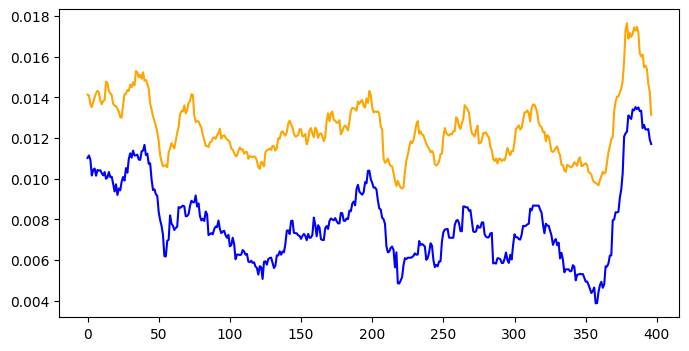

In [12]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

These results look promising!  Starting to believe we are on the right track with predicting volatility.  With some tuning we may be able to improve results.

I still have doubts about using historical returns to predict future returns, however.  For now I think we should focus on predicting volatility.

In [27]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
# The model seems to consistently overestimate future volatility
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds) - 0.0046)}')

R2: 0.8484148383140564
MAE: 0.0006199248018674552
RMSE: 0.0007666908204555511
MSE: 5.878147817384161e-07


If we correct for the observed bias in the model, our R-squared value looks good.  Not sure where the bias would be coming from, other than possibly the small sample size in the historical volatility feature computation (WINDOW_SIZE = 10 days).  A plot of bias-corrected predictions appears below.

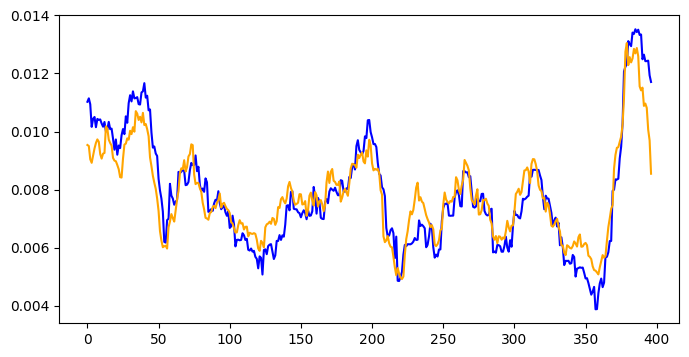

In [28]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds - 0.0046), color='orange')

After investigating a wide variety of models with varying inputs, the LSTM with limited input provides the most consistent results.  Going forward with this model, a final step will be to find a robust method for correcting the model's bias.  A naive approach would be to simply test a range of bias-correcting values and select the one that produces the highest R-squared value.

The bias in the model is likely due to the small sample size in the historical value (last 5 business days).  Smaller samples tend to have higher variance than large samples.  We are essentially trying to predict the variance of a random variable (return) over a 21-day outlook, but the feature we are using is a sample of the variance of this random variable over the last 5 business days.  Our small 5-business day feature sample will almost always have a higher variance than the longer 21-day outlook that we are trying to predict.